# Aula 61 - Calculando a Taxa de Retorno de um Ativo

### 1. Introdução

#### Por que diferentes níveis de risco e lucratividade?

Os **títulos públicos** têm, por exemplo, uma taxa de retorno de 3% (USA) a um baixíssimo risco, visto que pouquíssimas vezes o governo deu calote financeiro. Além disso, o investidor tem a garantia de que, a um determinado prazo, ele receberá o investimento inicial mais os juros.

**Ações de empresa** têm em torno de 6% (USA) da taxa de retorno, no entanto há grandes flutuações e mudança de preço. O investidor em ações sabe que para obter maior retorno, ele deve se expor às grandes flutuações e maiores riscos de negócio.

A arte das finanças precisa dimensionar duas variáveis importantíssimas:

- **risco;**

- **retorno.**

#### Calculando a Taxa de Retorno de um Ativo

Suponha que você fez um negócio com a Apple, comprou a 101.00 e vendeu a 116.00, além dos dividendos, proventos, etc. 

> **Será que 11.00 dólares é um bom lucro?**

Para responder esta pergunta, podemos considerar outros possíveis negócios de outras possíveis empresas.

Considere a Apple por 116.00 por ação, Samsung 944.00 por ação e Google 835.00 por ação.

Como elas têm preços diferentes, precisamos de uma medida que garanta **comparabilidade**, isto é, torne-as comparáveis. Esta medida pode ser o **percentual da taxa de retorno do investimento.**

- **Taxa de retorno simples:** 

$$ taxa de retorno = \frac {preco final - preco inicial} {preco inicial} * 100 $$

- **Taxa de retorno logarítmica:**

$$ log \frac {(preco final)} {(preco inicial)} \rightarrow log(preco final) - log(preco inicial) $$

- **Retorno simples x Retorno logarítmico:**

| Taxa de retorno simples | Taxa de retorno logarítmico
| :---------------------: | :------------------------:
| Ao lidar com vários ativos ao longo do mesmo período de tempo | Cálculos sobre um **único** ativo ao longo do tempo

> **Obs.: os investimentos com prazos diferentes não devem ser comparados**

---

- **Conversão de retornos diários, mensais e trimestrais para retornos ANUAIS**

$$ retorno anual = (retorno diario + 1)^{365} * 100 $$

# Aula 62: Calculando a Taxa de Retorno de um Ativo em Python - Retornos Simples - Parte I

### Retorno Simples - Parte I

In [1]:
# Import libs
import numpy as np
from pandas_datareader import data as wb
import matplotlib.pyplot as plt

In [2]:
# Importando dados da Procter & Gamble
PG = wb.DataReader('PG', data_source='yahoo', start='1995-1-1')

# Visualizando os dados
PG.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2021-04-05,137.250000,134.729996,134.960007,136.449997,8279100.0,136.449997
2021-04-06,137.020004,135.639999,136.000000,136.500000,6180600.0,136.500000
2021-04-07,137.330002,136.250000,137.119995,136.740005,10244500.0,136.740005
2021-04-08,137.630005,136.589996,136.899994,137.259995,6190300.0,137.259995
2021-04-09,137.270004,135.559998,136.509995,136.369995,5855400.0,136.369995


**Taxa de Retorno Simples**

$$ \frac {P_{n} - P_{n-1}} {P_{n-1}} = \frac {P_{n}} {P_{n-1}} - 1 $$


em que:

$ P $: preço de fechamento ajustado

$ n $: dia atual 
 
$ n-1 $: dia anterior

In [3]:
# Taxa de Retorno Simples
PG['retorno_simples'] = (PG['Adj Close'] / PG['Adj Close'].shift(1)) - 1

# Visualizando a nova coluna
PG['retorno_simples']

Date
1995-01-03         NaN
1995-01-04   -0.008016
1995-01-05   -0.014141
1995-01-06    0.002049
1995-01-09   -0.004090
                ...   
2021-04-05    0.016160
2021-04-06    0.000366
2021-04-07    0.001758
2021-04-08    0.003803
2021-04-09   -0.006484
Name: retorno_simples, Length: 6614, dtype: float64

# Aula 63: Calculando a Taxa de Retorno de um Ativo - Retorno Simples - Parte II

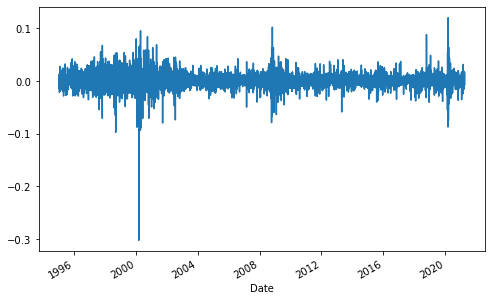

In [4]:
PG['retorno_simples'].plot(figsize=(8, 5))
plt.show();

Em finanças, é comum ter retornos negativos. Os retornos positivos são acumulados ao longo do tempo. Para o investidor de longo prazo, é mais interessante a **taxa de retorno média**, que é simplesmente repetir o cálculo anterior (da taxa de retorno simples) e extrair a média.

Faremos isso a seguir.

In [5]:
# Calculando a media da taxa de retorno diaria
taxa_retorno_media = PG['retorno_simples'].mean()

# Visualizando a taxa_retorno_media diaria
taxa_retorno_media

0.00052776170289138

In [6]:
# Anualizando o taxa_retorno_media
#retorno_anual = PG['retorno_simples'].mean()

# Visualizando a nova taxa_retorno_media
#retorno_anual_percentual = round(retorno_anual, 5) * 100

retorno_anual_percentual = PG['retorno_simples'].mean() * 250

# Deixando na forma percentual
print(round(retorno_anual_percentual, 5) * 100, '%')

13.194 %


---

Testando os códigos acima com outras ações.

In [7]:
# Importando as cotacoes do ITSA4
itau = wb.DataReader('ITSA4.SA', data_source='yahoo', start='2020-01-02', end='2021-01-04')

# Visualizando itau
itau.tail()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2020-12-23,11.72,11.40,11.46,11.67,27595400.0,11.584816
2020-12-28,11.80,11.67,11.74,11.80,12864200.0,11.713867
2020-12-29,11.88,11.74,11.81,11.87,16012900.0,11.783358
2020-12-30,11.94,11.70,11.89,11.73,23948900.0,11.644379
2021-01-04,11.84,11.43,11.84,11.55,39137400.0,11.465693


- Taxa de retorno simples:

$$ \frac {P_{n}} {P_{n-1}} - 1 $$

In [8]:
# Calculando a taxa de retorno simples
itau['retorno_simples'] = (itau['Adj Close'] / itau['Adj Close'].shift(1)) - 1

# Visualizando a nova coluna
itau['retorno_simples']

Date
2020-01-02         NaN
2020-01-03   -0.014634
2020-01-06   -0.002122
2020-01-07   -0.013466
2020-01-08   -0.015086
                ...   
2020-12-23    0.023684
2020-12-28    0.011140
2020-12-29    0.005932
2020-12-30   -0.011795
2021-01-04   -0.015345
Name: retorno_simples, Length: 248, dtype: float64

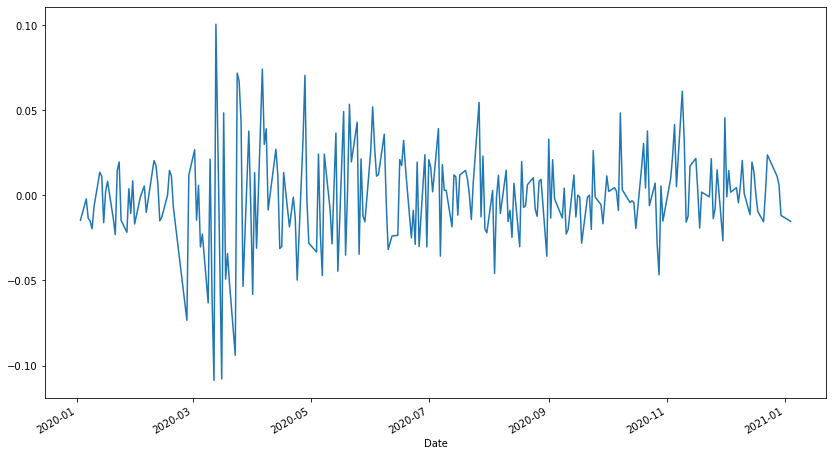

Taxa de retorno média anual do ITSA4 é: -8.203000000000001


In [9]:
# Plot
itau['retorno_simples'].plot(figsize=(14,8))
plt.show();

# Calculando a taxa de retorno media anual
retorno_media_d = itau['retorno_simples'].mean() * 250

# retorno_media_d percentual
retorno_media_d = round(retorno_media_d,5) * 100

# Printando o valor
print(f"Taxa de retorno média anual do ITSA4 é: {retorno_media_d}")

---

# Aula 64: Calculando a Taxa de Retorno de um Ativo - Retorno Logarítmicos

- Retorno Logarítmico:

$$ ln (\frac {P_{t}} {P_{t-1}} )$$

em que:

$ t = $ dia atual 

Retorno logarítmico é recomendada quando se trata de uma única ação.

In [10]:
PG.head()

,High,Low,Open,Close,Volume,Adj Close,retorno_simples
Date,,,,,,,
1995-01-03,15.62500,15.43750,15.46875,15.59375,3318400.0,8.166473,NaN
1995-01-04,15.65625,15.31250,15.53125,15.46875,2218800.0,8.101009,-0.008016
1995-01-05,15.43750,15.21875,15.37500,15.25000,2319600.0,7.986450,-0.014141
1995-01-06,15.40625,15.15625,15.15625,15.28125,3438000.0,8.002816,0.002049
1995-01-09,15.40625,15.18750,15.34375,15.21875,1795200.0,7.970086,-0.004090


In [11]:
# Retorno Logarítmico
PG['log_return'] = np.log(PG['Adj Close'] / PG['Adj Close'].shift(1))

# Imprimindo o valor
PG['log_return']

# Retorno médio diario
log_return_d = PG['log_return'].mean()

# Retorno médio anual
log_return_a = PG['log_return'].mean() * 250

# Retorno médio anual percentual
log_return_ap = round(log_return_a, 5) * 100

# Visualizando retorno médio anual percentual
print(f"O retorno médio anual percentual é {log_return_ap}%")

O retorno médio anual percentual é 10.642999999999999%


Repetindo os códigos acima para uma ação particular: `TAEE4.SA`

In [19]:
# Importando os dados
taesa = wb.DataReader('TAEE4.SA', data_source='yahoo', start='2020-01-04', end='2021-01-02')

# Lendo as primeiras entradas
taesa.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2020-01-06,10.43,10.20,10.43,10.35,49900.0,9.318160
2020-01-07,10.35,10.15,10.34,10.19,68200.0,9.174111
2020-01-08,10.25,9.83,10.25,10.06,98700.0,9.057071
2020-01-09,10.20,9.90,10.20,10.07,81500.0,9.066075
2020-01-10,10.21,10.07,10.14,10.14,35700.0,9.129096


In [21]:
# Calculando a taxa de retorno logarítmica
taesa['log_return'] = np.log(taesa['Adj Close'] / taesa['Adj Close'].shift(1))

# Visualizando
taesa['log_return']

# Tirando a média, q é o retorno logarítmico diário
log_return_d = taesa['log_return'].mean()

# Anualizando a media
log_return_a = log_return_d * 250

# Porcentagem do retorno logarítmico anual
print(f"A taxa de retorno anual é de {round(log_return_a, 5) * 100}%")

A taxa de retorno anual é de 18.756%


---

# Aula 65: O que é um portfólio de ações e como calcular a sua taxa de retorno

Imagine um portfólio de ações como uma cesta de alimentos, em que os alimentos são diferentes ações.

Como foi aprendido a calcular a taxa de retorno de cada ação individualmente, então sabemos, intuitivamente, como calcular a taxa de retorno de um portfólio. Basta que façamos a taxa de retorno média anual de cada ação **multiplicada** pelo seu peso na carteira e, após feito isso, somá-las. Lembre-se que:

> a soma de todos os pesos deve ser menor ou igual a 1.

Suponha que temos 4 ações com quantidades iguais, ou seja, $ \frac {1} {4} = 0.25 $.

Seja $ R $ o retorno esperado, $ W $ o peso do ativo. Temos:

$$ R_{e} = W_{1} x R_{1} + W_{2} x R_{2} + W_{3} x R_{3} + W_{4} x R_{4} $$

$$ R_{e} = 0.25 x R_{1} + 0.25 x R_{2} + 0.25 x R_{3} + 0.25 x R_{4} $$

# Aula 66: Calculando a taxa de retorno de um portfólio em Python

In [12]:
import pandas as pd

In [22]:
# Lista com os tickers: Procter & Gamble, Microsoft, Ford, General Electric
tickers = ['PG', 'MSFT', 'F', 'GE']
# criando um dataframe vazio
df1 = pd.DataFrame()

# armazenar em df1, os Adj Close de cada ticker da lista tickers
for ticker in tickers:
    df1[ticker] = wb.DataReader(ticker, data_source='yahoo', start='2020-01-04', end='2021-01-04')['Adj Close']
    
# Visualizando o nosos dataframe df1
df1.head()

,PG,MSFT,F,GE
Date,,,,
2020-01-06,119.073143,157.001373,9.006823,12.069806
2020-01-07,118.335899,155.569855,9.095318,11.980326
2020-01-08,118.840317,158.047836,9.095318,11.870962
2020-01-09,120.140190,160.022308,9.105151,11.841135
2020-01-10,120.256592,159.281876,9.095318,11.602523


In [23]:
df1.head()

,PG,MSFT,F,GE
Date,,,,
2020-01-06,119.073143,157.001373,9.006823,12.069806
2020-01-07,118.335899,155.569855,9.095318,11.980326
2020-01-08,118.840317,158.047836,9.095318,11.870962
2020-01-09,120.140190,160.022308,9.105151,11.841135
2020-01-10,120.256592,159.281876,9.095318,11.602523


Antes de prosseguirmos, precisamos utilizar a técnica de **normalização** dos dados, que nada mais é do que deixar todos os dados "na mesma página" para poder compará-los igualmente.

Existem várias técnicas e para deixar registrado uma referência para consulta futura, neste link encontrará mais explicações: [Porquê e quando normalizar os dados?](https://medium.com/tentando-ser-um-unic%C3%B3rnio/porqu%C3%AA-e-quando-%C3%A9-necess%C3%A1rio-normalizar-os-dados-92e5cce445aa#:~:text=O%20objetivo%20da%20normaliza%C3%A7%C3%A3o%20%C3%A9,diferen%C3%A7as%20nos%20intervalos%20de%20valores.&text=A%20renda%20%C3%A9%20cerca%20de,os%20intervalos%20s%C3%A3o%20muito%20diferentes).

Neste projeto, normalizaremos os dados para a base 100 através da fórmula abaixo.

$$ \frac {P_{t}} {P_{0}} * 100 $$

em que:

$ P_{t} $: preço no dia atual

$ P_{0} $: preço no dia 0, ou seja, primeiro dia, primeiro preço.

O código python que nos permite pegar o preço no dia 0 é:
`df1.iloc[0]`

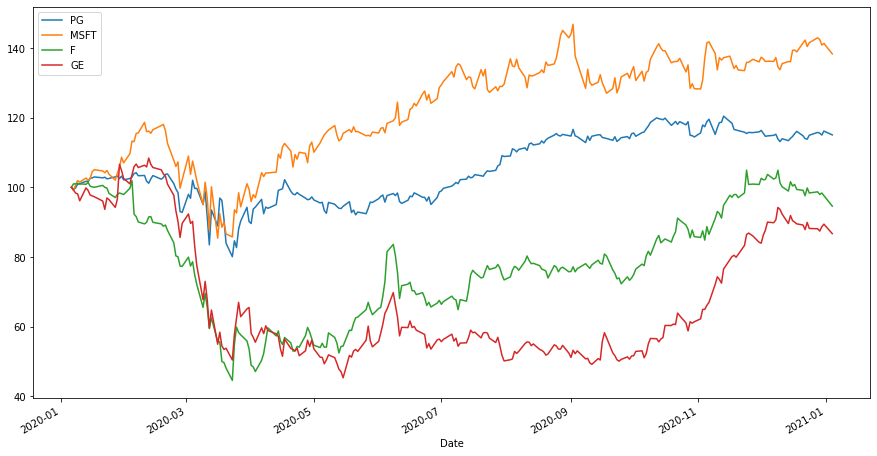

In [24]:
# Aplicando a fórmula de normalizacao para a base 100
dados_normalizados = df1 / df1.iloc[0] * 100

# Plotando
dados_normalizados.plot(figsize=(15,8))
plt.show();

Calculando a taxa de retorno de um portfólio

In [16]:
# Taxa de retorno simples de cada ativo
retorno = (df1 / df1.shift(1)) - 1

# Array com os pesos (25%) de cada ativo
pesos = np.array([0.25, 0.25, 0.25, 0.25])

# Dado que o retorno é uma matriz e o pesos é um vetor-coluna
# quando formos multiplicá-los, precisamos da transposta da matriz
# resumidamente, é dado pelo np.dot, que permite calcular produtos vetoriais ou matrizes rapidamente
np.dot(retorno, pesos)

array([            nan, -3.22440205e-03,  2.76560277e-03,  5.49984751e-03,
       -6.22231901e-03,  1.42110235e-02, -2.64475050e-03, -1.85071731e-03,
        3.62330438e-03,  1.16734608e-03, -3.34121827e-03, -8.34009000e-03,
        8.64530688e-03, -7.32287475e-03, -1.19019494e-02,  1.41623981e-02,
        2.88963479e-02,  4.20955835e-03, -1.23940641e-02,  7.79758825e-03,
        2.14214252e-02, -1.61458292e-02,  5.77856198e-03, -8.28938118e-03,
        6.73519592e-03, -9.54770038e-03,  9.28837035e-03, -2.17144541e-03,
       -2.07810775e-03, -2.77464629e-03, -2.71529194e-03, -2.19432491e-03,
       -1.76113954e-02, -3.55861904e-02, -3.05283852e-02, -8.35390007e-03,
       -5.25784465e-02,  1.68899887e-02,  4.68142033e-02, -3.02319820e-02,
        2.81244540e-02, -4.39055533e-02, -3.29117060e-02, -8.28268009e-02,
        6.15104288e-02, -6.23631351e-02, -9.86996723e-02,  1.00087372e-01,
       -1.14484165e-01,  5.87923383e-02, -5.45926299e-02, -1.61899519e-02,
       -3.46243869e-02, -

Esta saída é indesejada, porém foi causada devido ao fato de termos utilizado o retorno diário, quando, na verdade, precisamos do médio.

In [17]:
# Retorno médio anual
retorno_anual = retorno.mean() * 250

# Calculando novamente o produto vetorial
np.dot(retorno_anual, pesos)

# Calculando o retorno anual percentual do portfolio 1 (pf1)
pf1 = round(np.dot(retorno_anual, pesos), 4) * 100

print(f"A taxa de retorno anual do portfólio 1 é {pf1}%")

A taxa de retorno anual do portfólio 1 é 19.17%


In [18]:
# Atribuindo novos pesos
pesos2 = np.array([0.4, 0.4, 0.15, 0.05])

# Portfolio 2
pf2 = round(np.dot(retorno_anual, pesos2), 2) * 100

# Imprimindo
print(f"Portfólio 1: {pf1}%\nPortfólio 2: {pf2}%")

Portfólio 1: 19.17%
Portfólio 2: 26.0%


Replicando os códigos anteriores em ações pessoais: `USIM5.SA`, `ITSA4.SA`, `TAEE4.SA`, `SAPR4.SA`.

In [26]:
# Funcao para pegar os tickers
def ticker(df, tickers, start, end):
    for t in tickers:
        df[t] = wb.DataReader(t, start, end, data_source='yahoo')['Adj Close']

In [34]:
# Escolhendo os tickers
tickers = ['USIM5.SA', 'ITSA4.SA', 'TAEE4.SA', 'SAPR4.SA']

# Criando um dataframe vazio
df2 = pd.DataFrame()

# Salvando os preos ajustados para um dataframe
for ticker in tickers:
    df2[ticker] = wb.DataReader(ticker, data_source='yahoo', start='2020-01-04', end='2021-01-02')['Adj Close']

# Visualizando as primeiras entradas de df2
df2.head()

,USIM5.SA,ITSA4.SA,TAEE4.SA,SAPR4.SA
Date,,,,
2020-01-06,9.333100,13.482615,9.318160,6.117793
2020-01-07,9.422270,13.301064,9.174111,6.262460
2020-01-08,9.303377,13.100402,9.057071,6.259245
2020-01-09,9.243930,12.842405,9.066075,6.243171
2020-01-10,9.055683,12.756408,9.129096,6.268890


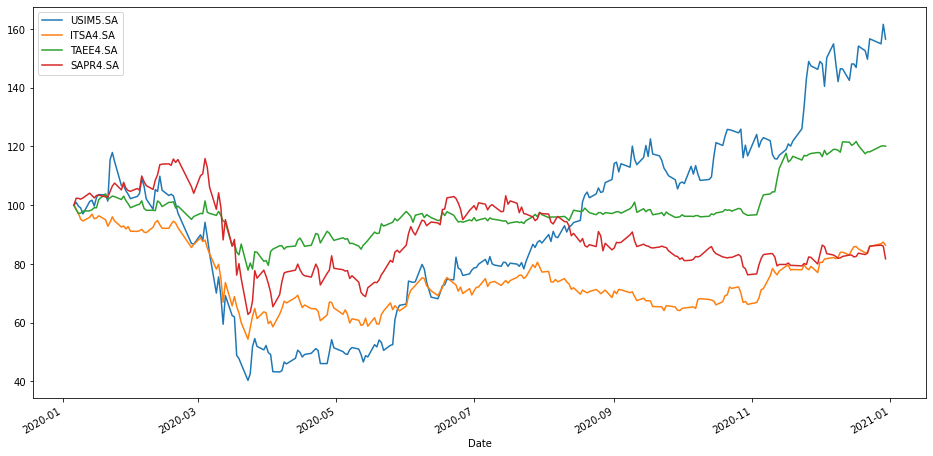

In [36]:
# Normalizacao dos dados
dados_normalizados = df2 / df2.iloc[0] * 100

# Plotando
dados_normalizados.plot(figsize=(16,8))
plt.show();